# Day 4 — EDA Part 1: Distributions & Outliers

Univariate analysis of the diabetes dataset using Seaborn: distributions, outlier detection with the IQR method, and categorical class balance.

## Loading the Dataset
Load the dataset and take a first look at its shape and structure before doing any deeper analysis.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("diabetes.csv")

print (df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


The dataset has 768 rows and 9 columns. .head() shows the first few samples, giving an initial sense of the features available (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome).

## Initial Inspection
Before visualizing anything, check the data types, structure, missing values, and summary statistics — this is what tells us whether the data is clean enough to analyze.

In [29]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

All columns are numeric (int64 or float64), so every feature can be visualized directly with histograms and box plots.

.info() confirms the same column count and types shown by .dtypes, and shows 768 non-null entries in every column — a first signal that there may be no missing data.

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


.isna().sum() confirms there are zero missing values in every column. Note this only checks for NaN — it does not catch values like 0 used as a placeholder for "missing," which some columns here (e.g. Insulin, SkinThickness) may actually contain.

In [31]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

describe() gives the count, mean, standard deviation, and quartiles for every numeric column. This is useful for spotting potential data quality issues before plotting. For example, some medical measurement columns, such as Glucose, BloodPressure, SkinThickness, and Insulin, contain minimum values of 0, which may represent missing measurements rather than true physiological values. These values should be investigated before modeling.

In [32]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Step 1 — Histogram for Each Numeric Variable
Produce a histogram for every numeric variable to see the shape of its distribution — skewed, symmetric, multi-modal, etc.

Each subplot shows the distribution of one numeric feature. Several variables, such as Age and Insulin, show right-skewed distributions, while BMI appears more approximately bell-shaped. The histograms also reveal unusual concentrations of zero values in some medical measurement columns. These distribution patterns motivate further investigation using box plots and the IQR method.

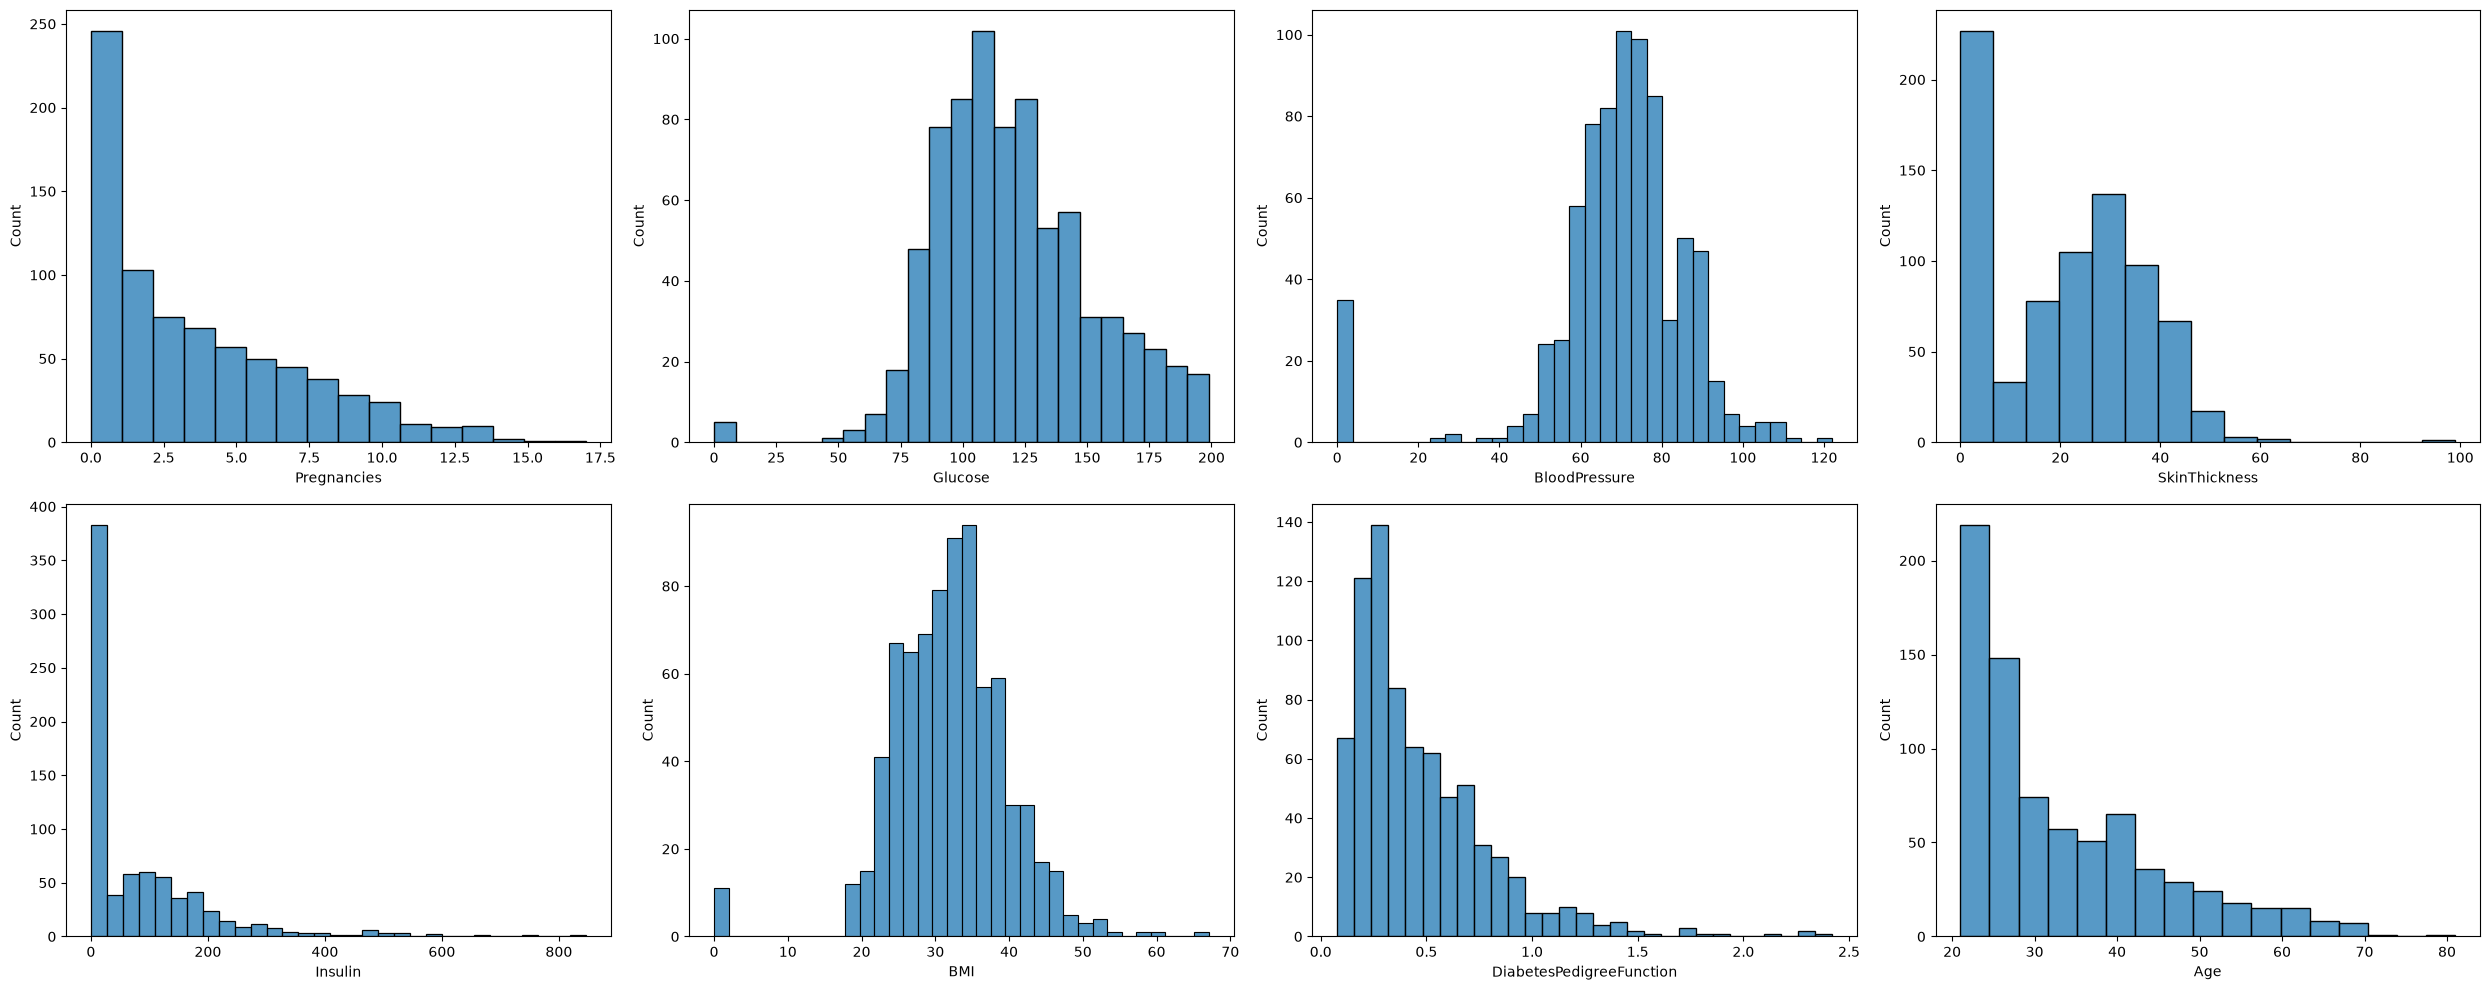

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(25, 10))

sns.histplot(data=df, x="Pregnancies", ax=axes[0,0])
sns.histplot(data=df, x="Glucose", ax=axes[0,1])
sns.histplot(data=df, x="BloodPressure", ax=axes[0,2])
sns.histplot(data=df, x="SkinThickness", ax=axes[0,3])
sns.histplot(data=df, x="Insulin", ax=axes[1,0])
sns.histplot(data=df, x="BMI", ax=axes[1,1])
sns.histplot(data=df, x="DiabetesPedigreeFunction", ax=axes[1,2])
sns.histplot(data=df, x="Age", ax=axes[1,3])


plt.tight_layout()
plt.show()

## Step 2 — Box Plots to Identify Outliers Visually
Produce box plots for key numeric variables (Glucose, Insulin, DiabetesPedigreeFunction) to see the median, quartiles, and any points that fall beyond the whiskers.

The points plotted beyond the whiskers represent potential outliers according to the box plot rule. Insulin shows the most noticeable extreme values, with several points above the upper whisker. This is consistent with the right-skewed distribution observed in its histogram, making Insulin a suitable variable for further investigation using the IQR method.

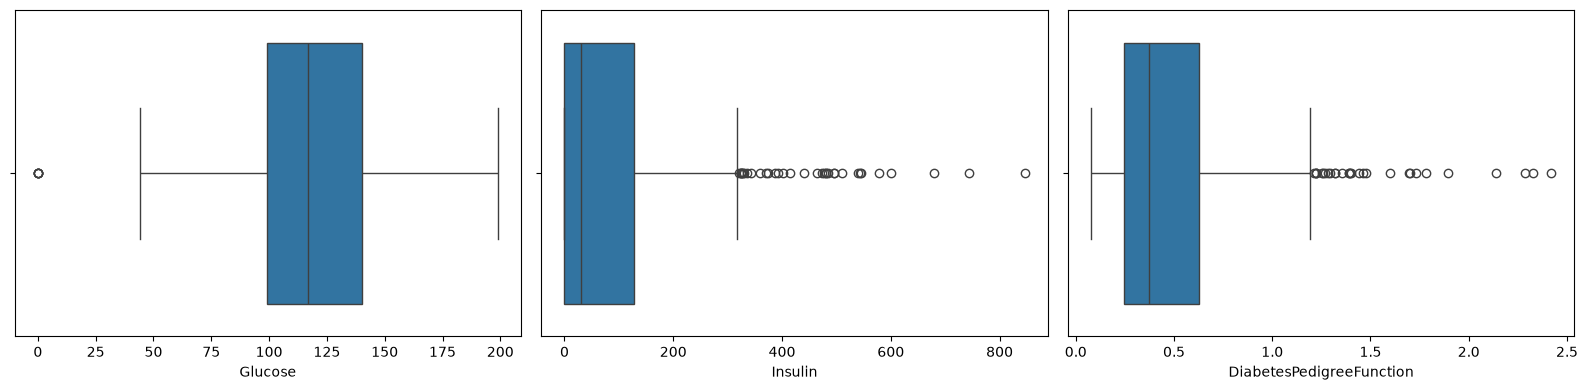

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, x="Glucose" , ax=axes[0])
sns.boxplot(data=df, x="Insulin",ax=axes[1])
sns.boxplot(data=df, x="DiabetesPedigreeFunction",ax=axes[2])

plt.tight_layout()
plt.show()

## Step 3 — Flagging Outliers with the IQR Method
Apply the IQR rule to the Insulin column: flag any value below Q1 - 1.5*IQR or above Q3 + 1.5*IQR as a potential outlier.

**Result**: The IQR method flagged 34 observations in the Insulin column as potential outliers. Most of these values are above the upper IQR boundary, which is consistent with the extreme values observed in the box plot.

**Decision**: The detected outliers will not be removed automatically. These values may represent genuine observations rather than data-entry errors, so further investigation or domain knowledge would be needed before removing them. However, the Insulin column also contains many 0 values, which may represent missing measurements rather than true insulin levels. Therefore, these zero values should be investigated and handled separately, while the high non-zero values will be retained for now. Outliers should not be removed without a clear justification..

In [35]:
Q1 = df["Insulin"].quantile(0.25)

Q3 = df["Insulin"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Insulin"] < lower_bound) | (df["Insulin"] > upper_bound)]

print (len(outliers))
outliers["Insulin"]

34


8      543
13     846
54     342
111    495
139    325
153    485
186    495
220    478
228    744
231    370
247    680
248    402
258    375
286    545
296    360
360    325
370    465
375    325
392    415
409    579
415    474
480    328
486    480
519    326
574    330
584    600
612    321
645    440
655    540
695    480
707    335
710    387
715    392
753    510
Name: Insulin, dtype: int64

## Step 4 — Count Plot for the Categorical Variable
Produce a count plot for the categorical variable (Outcome) to see how the classes are distributed.

**Class imbalance**: The Outcome variable contains two classes: 0 represents no diabetes and 1 represents diabetes. The classes are not evenly distributed, with more observations in class 0 than class 1. This indicates a moderate class imbalance that should be considered before modeling, as a classifier may favor the majority class. Techniques such as stratified splitting, resampling, or class weighting can be considered during the modeling stage.

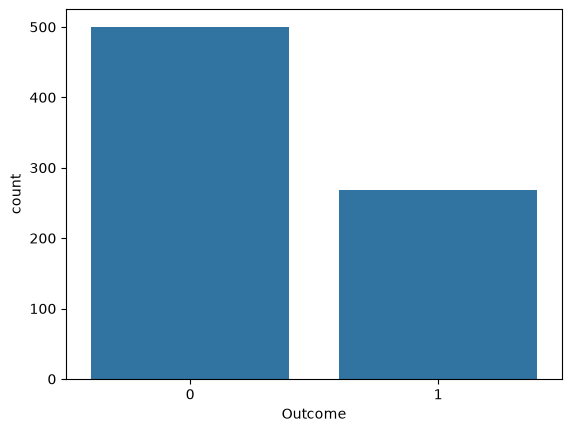

In [36]:
sns.countplot(data=df, x="Outcome")
plt.show()

## Step 5 — Summary of What Each Distribution Reveals
- **Pregnancies, Age, Insulin:** These variables show varying degrees of right skewness, with Insulin displaying the most noticeable extreme values. The IQR method flagged 34 potential outliers in the Insulin column.
- **Glucose, BloodPressure, BMI:** These variables show different distribution patterns. BMI appears relatively bell-shaped, while Glucose and BloodPressure show some deviations from a symmetric distribution. The presence of 0 values in medical measurement columns should be investigated, as they may represent missing measurements rather than true values.
- **SkinThickness:** Contains a noticeable number of 0 values, which may indicate missing measurements rather than true skin thickness values. This should be investigated during the data preprocessing stage.
- **DiabetesPedigreeFunction:** Shows some right skewness, with several high-value observations identified visually in the box plot.
- **Outcome (categorical):** imbalanced — more non-diabetic than diabetic cases, which needs to be accounted for before modeling.

**Overall takeaway:** the dataset is clean in the sense that .isna() shows no NaNs, but it is not clean in the sense that matters most — several numeric columns use 0 as a stand-in for missing values, and the target class is imbalanced. Both issues were only visible because EDA was done *before* modeling, exactly why EDA is a required first step.